In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/ppe-project', exist_ok=True)
%cd /content/drive/MyDrive/ppe-project

Mounted at /content/drive
/content/drive/MyDrive/ppe-project


In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="RYjUPdnRCS5m2CaZPWHl")
project = rf.workspace("roboflow-universe-projects").project("construction-site-safety")
version = project.version(27)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Construction-Site-Safety-27 in yolov8:: 100%|██████████| 5610/5610 [01:29<00:00, 62.49it/s]


In [6]:
import os
print(os.listdir('.'))

['Construction-Site-Safety-27']


In [7]:
print(os.listdir('Construction-Site-Safety-27'))

['README.dataset.txt', 'README.roboflow.txt', 'data.yaml', 'test', 'train', 'valid']


In [8]:
import yaml
with open('Construction-Site-Safety-27/data.yaml', 'r') as f:
    config = yaml.safe_load(f)
print(config['names'])
print(len(config['names']), 'classes')

['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']
10 classes


In [9]:
import yaml
with open('Construction-Site-Safety-27/data.yaml', 'r') as f:
    config = yaml.safe_load(f)
print(config['names'])

['Hardhat', 'Mask', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest', 'machinery', 'vehicle']


##Image Count

In [10]:
import os

for split in ['train', 'valid', 'test']:
    img_count = len(os.listdir(f'Construction-Site-Safety-27/{split}/images'))
    print(f"{split}: {img_count} images")

train: 2603 images
valid: 114 images
test: 82 images


## Class Distribution

In [11]:
from collections import Counter

class_counts = Counter()
for split in ['train', 'valid', 'test']:
    label_dir = f'Construction-Site-Safety-27/{split}/labels'
    for label_file in os.listdir(label_dir):
        with open(f'{label_dir}/{label_file}') as f:
            for line in f:
                class_id = int(line.split()[0])
                class_counts[class_id] += 1

for class_id, count in sorted(class_counts.items()):
    print(f"{config['names'][class_id]}: {count}")

Hardhat: 3551
Mask: 1792
NO-Hardhat: 2428
NO-Mask: 3362
NO-Safety Vest: 4153
Person: 10031
Safety Cone: 3306
Safety Vest: 3258
machinery: 5337
vehicle: 1617


##Bar Chart

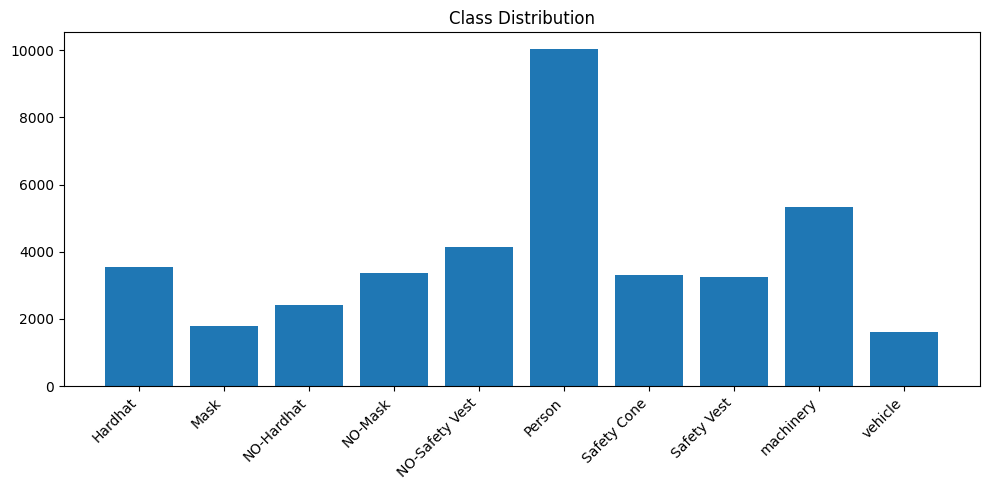

In [12]:
import matplotlib.pyplot as plt

names = [config['names'][i] for i in sorted(class_counts.keys())]
counts = [class_counts[i] for i in sorted(class_counts.keys())]

plt.figure(figsize=(10,5))
plt.bar(names, counts)
plt.xticks(rotation=45, ha='right')
plt.title('Class Distribution')
plt.tight_layout()
plt.savefig('class_distribution.png')
plt.show()

Visualization

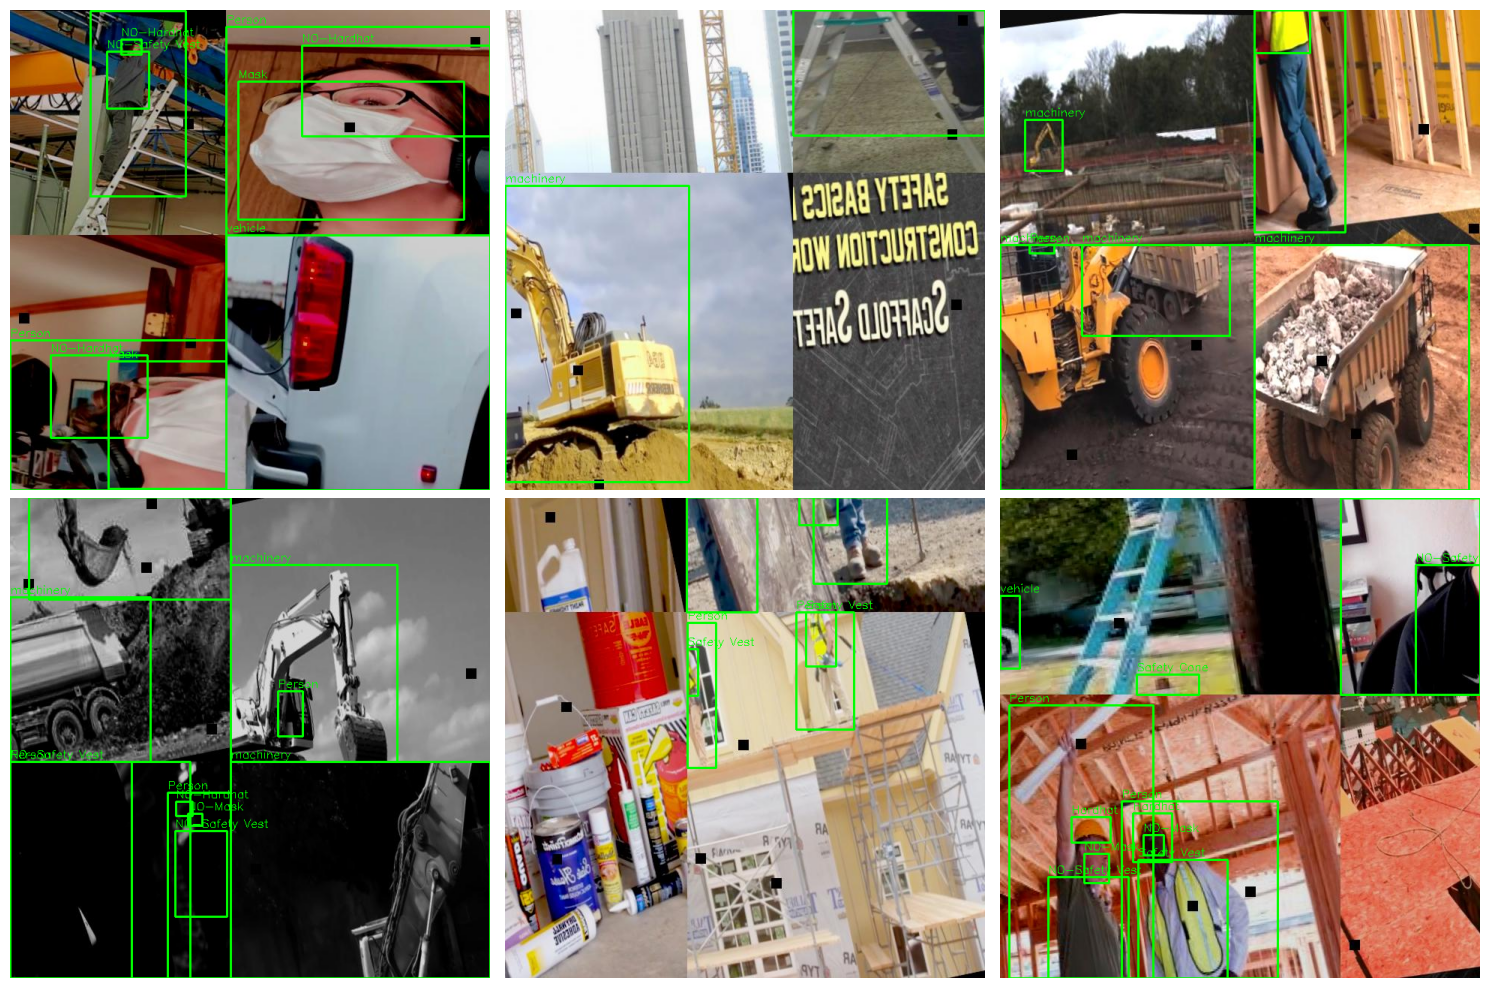

In [13]:
import cv2
import matplotlib.pyplot as plt
import random

img_dir = 'Construction-Site-Safety-27/train/images'
label_dir = 'Construction-Site-Safety-27/train/labels'
sample_files = random.sample(os.listdir(img_dir), 6)

fig, axes = plt.subplots(2, 3, figsize=(15,10))
for ax, img_file in zip(axes.flat, sample_files):
    img_path = f'{img_dir}/{img_file}'
    label_path = f'{label_dir}/{img_file.rsplit(".",1)[0]}.txt'
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                cls, x, y, bw, bh = map(float, line.split())
                x1, y1 = int((x-bw/2)*w), int((y-bh/2)*h)
                x2, y2 = int((x+bw/2)*w), int((y+bh/2)*h)
                cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
                cv2.putText(img, config['names'][int(cls)], (x1,y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.tight_layout()
plt.savefig('sample_annotations.png')
plt.show()